# 01 · Exploratory Data Analysis

**Goal:** understand the mock MRO dataset before modelling, and turn each finding into a concrete
data-preparation or modelling decision.

Prediction target: *will this component have an **unscheduled removal within the next 30 flight cycles**?*

Sections
1. Dataset overview
2. Removals: what we are predicting
3. Missing data
4. Outliers and sensor glitches
5. Is there a precursor signal?
6. Age / usage effect
7. Leakage traps
8. Decisions carried into the pipeline

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from src.config import RAW_DIR, HORIZON_FC
from src import viz

pd.set_option("display.width", 140)
pd.set_option("display.max_columns", 20)
R = RAW_DIR
aircraft = pd.read_csv(R / "aircraft.csv")
parts = pd.read_csv(R / "parts_catalog.csv", dtype={"ata_chapter": str})
components = pd.read_csv(R / "components.csv")
ins = pd.read_csv(R / "installations.csv", parse_dates=["install_date", "removal_date"])
usage = pd.read_csv(R / "flight_usage.csv", parse_dates=["flight_date"])
sensors = pd.read_csv(R / "sensor_readings.csv", parse_dates=["reading_date"])
faults = pd.read_csv(R / "fault_codes.csv", parse_dates=["fault_date"], dtype={"ata_chapter": str})
maint = pd.read_csv(R / "maintenance_history.csv", parse_dates=["event_date"])
removals = pd.read_csv(R / "removals.csv", parse_dates=["removal_date"])
SENSOR_COLS = ["vibration_ips", "temperature_c", "pressure_psi"]

## 1. Dataset overview

In [2]:
tables = dict(aircraft=aircraft, parts_catalog=parts, components=components, installations=ins,
              flight_usage=usage, sensor_readings=sensors, fault_codes=faults,
              maintenance_history=maint, removals=removals)
pd.DataFrame({"rows": {k: len(v) for k, v in tables.items()},
              "columns": {k: v.shape[1] for k, v in tables.items()}})

,rows,columns
aircraft,40,6
parts_catalog,13,8
components,1640,6
installations,4175,10
flight_usage,29240,6
sensor_readings,730539,6
fault_codes,20856,8
maintenance_history,10155,8
removals,3015,11


In [3]:
print("Period:", usage.flight_date.min().date(), "->", usage.flight_date.max().date())
print("Aircraft by type:", aircraft.aircraft_type.value_counts().to_dict())
print("Aircraft by climate:", aircraft.climate_zone.value_counts().to_dict())
print(f"Installed positions: {parts.qty_per_aircraft.sum() * len(aircraft):,}")
print(f"Mean daily cycles per aircraft (flying days): {usage.query('flight_cycles > 0').flight_cycles.mean():.2f}")

Period: 2024-01-01 -> 2025-12-31
Aircraft by type: {'A320neo': 14, 'A321neo': 13, 'B737-800': 13}
Aircraft by climate: {'HOT_SANDY': 16, 'TEMPERATE': 15, 'HOT_HUMID': 9}
Installed positions: 1,160
Mean daily cycles per aircraft (flying days): 4.95


## 2. Removals: what we are predicting

In [4]:
removals.groupby(["removal_type", "removal_reason"]).size().rename("count").to_frame()

count
removal_type removal_reason            
SCHEDULED    OPPORTUNISTIC_CHECK     88
             WEAR_LIMIT             160
UNSCHEDULED  FAILURE_CONFIRMED     2654
             NO_FAULT_FOUND         113

Only **UNSCHEDULED** removals are positives. That includes No-Fault-Found (NFF): the unit was fine, but the
removal still cost an unplanned aircraft visit. Scheduled removals (wear limit, opportunistic during a check)
are planned events, so they are **not** positives. They end the installation, so the unit is simply no
longer observed afterwards.

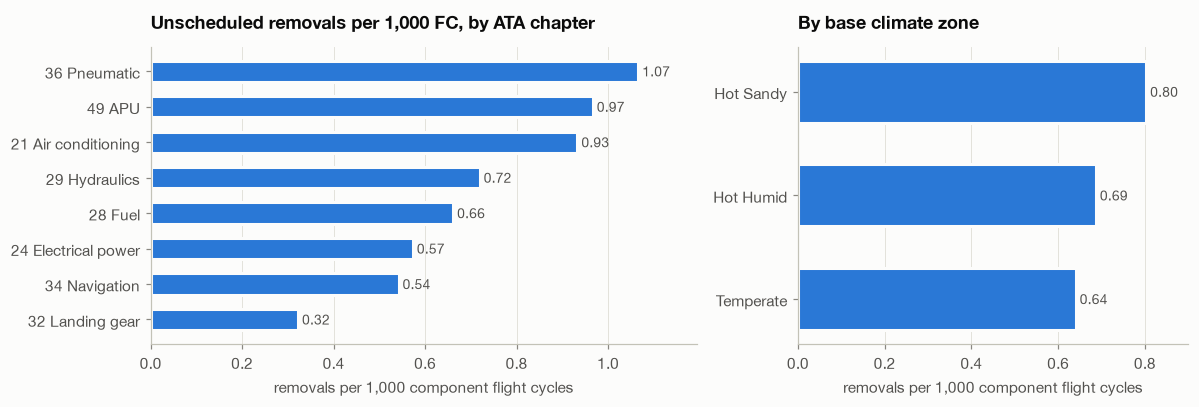

In [5]:
# Unscheduled removal rate per 1,000 flight cycles, by ATA chapter and by climate zone
unsched = removals.query("removal_type == 'UNSCHEDULED'").merge(parts[["part_no", "ata_chapter", "part_description"]], on="part_no")
unsched = unsched.merge(aircraft[["tail_no", "climate_zone", "aircraft_type"]], on="tail_no")

fleet_fc = usage.merge(aircraft[["tail_no", "climate_zone"]], on="tail_no")
fc_by_climate = fleet_fc.groupby("climate_zone").flight_cycles.sum()
qty_by_ata = parts.groupby("ata_chapter").qty_per_aircraft.sum()
fc_per_ac = usage.flight_cycles.sum() / len(aircraft)

ata_rate = (unsched.groupby("ata_chapter").size() / (qty_by_ata * fc_per_ac * len(aircraft)) * 1000).sort_values(ascending=False)
clim_rate = (unsched.groupby("climate_zone").size() / (fc_by_climate * parts.qty_per_aircraft.sum()) * 1000).sort_values(ascending=False)

ATA_NAMES = {"21": "21 Air conditioning", "24": "24 Electrical power", "28": "28 Fuel", "29": "29 Hydraulics",
             "32": "32 Landing gear", "34": "34 Navigation", "36": "36 Pneumatic", "49": "49 APU"}
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8), gridspec_kw={"width_ratios": [1.4, 1]})
viz.barh(axes[0], [ATA_NAMES[a] for a in ata_rate.index], ata_rate.values, fmt="{:.2f}")
axes[0].set_title("Unscheduled removals per 1,000 FC, by ATA chapter")
axes[0].set_xlabel("removals per 1,000 component flight cycles")
viz.barh(axes[1], [c.replace("_", " ").title() for c in clim_rate.index], clim_rate.values, fmt="{:.2f}")
axes[1].set_title("By base climate zone")
axes[1].set_xlabel("removals per 1,000 component flight cycles")
fig.tight_layout()
viz.savefig(fig, "eda_removal_rates")
plt.show()

**Finding:** removal rates differ by system (APU and pneumatic valves fail most often) and hot/sandy bases
run noticeably higher than temperate ones. → `ata_chapter`, `part_no` and `climate_zone` are useful
categorical features, and part-number-level baselines (MTBUR) are needed to compare usage across parts.

## 3. Missing data

In [6]:
# (a) value-level NaNs in rows that were reported
value_nan = sensors[SENSOR_COLS].isna().mean()

# (b) whole days with no report at all while the aircraft flew (data-link outages)
flying_days = usage.query("flight_cycles > 0")[["flight_date", "tail_no"]]
reported = sensors[["reading_date", "tail_no"]].drop_duplicates().rename(columns={"reading_date": "flight_date"})
cov = flying_days.merge(reported.assign(has=1), on=["flight_date", "tail_no"], how="left")
outage_share = cov.has.isna().mean()

# (c) rows where all three channels are NaN at once (single-unit dropouts)
all_nan = sensors[SENSOR_COLS].isna().all(axis=1).mean()
pd.DataFrame({
    "share": [value_nan.mean(), all_nan, outage_share],
}, index=["NaN values in reported rows (any channel)",
          "Rows with all channels NaN (unit dropout)",
          "Flying tail-days with no sensor report (data-link outage)"]).style.format("{:.1%}")

,share
NaN values in reported rows (any channel),7.7%
Rows with all channels NaN (unit dropout),4.3%
Flying tail-days with no sensor report (data-link outage),6.5%


In [7]:
# Dropouts come in runs of consecutive days, not as isolated points
s = sensors.sort_values(["tail_no", "position", "reading_date"])
s["dropout"] = s[SENSOR_COLS].isna().all(axis=1)
run_id = (s.dropout != s.groupby(["tail_no", "position"]).dropout.shift()).cumsum()
runs = s[s.dropout].groupby(run_id[s.dropout]).size()
print(f"Dropout runs: {len(runs):,}  median length {runs.median():.0f} days  max {runs.max()} days")

Dropout runs: 4,656  median length 6 days  max 25 days


**Finding:** three different missingness mechanisms. Random single NaNs (~3.5% per channel), multi-day
unit dropouts, and multi-day whole-aircraft outages. None is related to the label by construction, but
in real data a sensor going silent can itself be a symptom.

→ **Decision:** use trees' native NaN handling, rolling-window statistics computed over *available*
readings (so a few missing days don't erase a trend), plus explicit `sensor_missing_ratio_7d` and
`days_since_last_reading` features. For the linear model, impute with the train-set median by part number.

## 4. Outliers and sensor glitches

In [8]:
glitch = pd.DataFrame({c: {"== 0": (sensors[c] == 0).sum(), "== -999": (sensors[c] == -999).sum(),
                           "== 9999": (sensors[c] == 9999).sum()} for c in SENSOR_COLS})
glitch

,vibration_ips,temperature_c,pressure_psi
== 0,264,229,270
== -999,246,238,224
== 9999,249,242,248


In [9]:
# Spikes: robust z-score against each position's own median / MAD
clean = sensors[SENSOR_COLS].where(~sensors[SENSOR_COLS].isin([0, -999, 9999]))
g = clean.groupby([sensors.tail_no, sensors.position])
med, mad = g.transform("median"), g.transform(lambda x: (x - x.median()).abs().median())
rz = (clean - med) / (1.4826 * mad)
print("Share of values with |robust z| > 6:")
print((rz.abs() > 6).mean().map("{:.2%}".format).to_string())

Share of values with |robust z| > 6:
vibration_ips    0.18%
temperature_c    0.20%
pressure_psi     0.19%


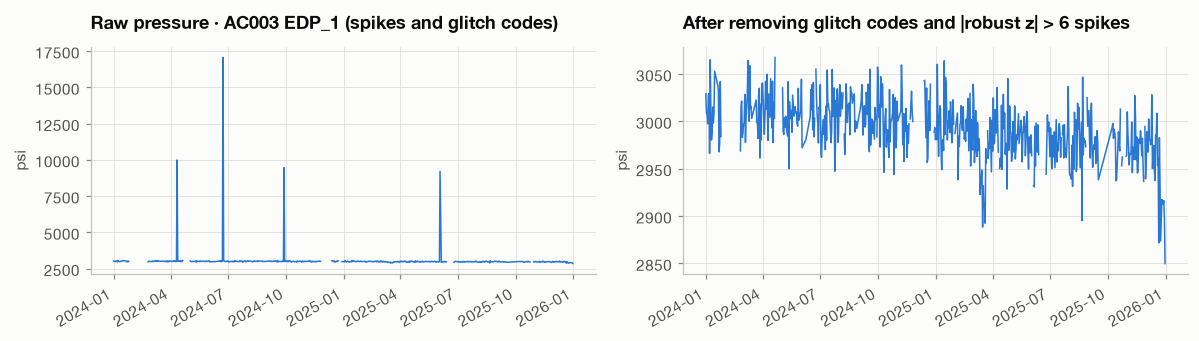

In [10]:
# Example: one position with its glitches and spikes
ex = sensors[(sensors.tail_no == "AC003") & (sensors.position == "EDP_1")].sort_values("reading_date")
fig, axes = plt.subplots(1, 2, figsize=(11, 3.2))
axes[0].plot(ex.reading_date, ex.pressure_psi, color=viz.SERIES[0], lw=1)
axes[0].set_title("Raw pressure · AC003 EDP_1 (spikes and glitch codes)")
exc = ex.pressure_psi.where(~ex.pressure_psi.isin([0, -999, 9999]))
exc = exc.where((exc - exc.median()).abs() < 6 * 1.4826 * (exc - exc.median()).abs().median())
axes[1].plot(ex.reading_date, exc, color=viz.SERIES[0], lw=1)
axes[1].set_title("After removing glitch codes and |robust z| > 6 spikes")
for a in axes:
    a.set_ylabel("psi")
fig.autofmt_xdate()
fig.tight_layout()
viz.savefig(fig, "eda_outliers_example")
plt.show()

**Finding:** two kinds of bad values. (1) Sentinel glitch codes `0`, `-999`, `9999` that are physically
impossible. (2) Short multiplicative spikes. Real degradation also produces *high* values, so outliers must
**not** be clipped blindly.

→ **Decision:** set sentinel codes and physically impossible values to NaN; remove single-point spikes
with a robust z-score against the unit's own recent history; aggregate with medians / rolling windows so
isolated spikes don't drive features, while a sustained drift still does.

## 5. Is there a precursor signal?

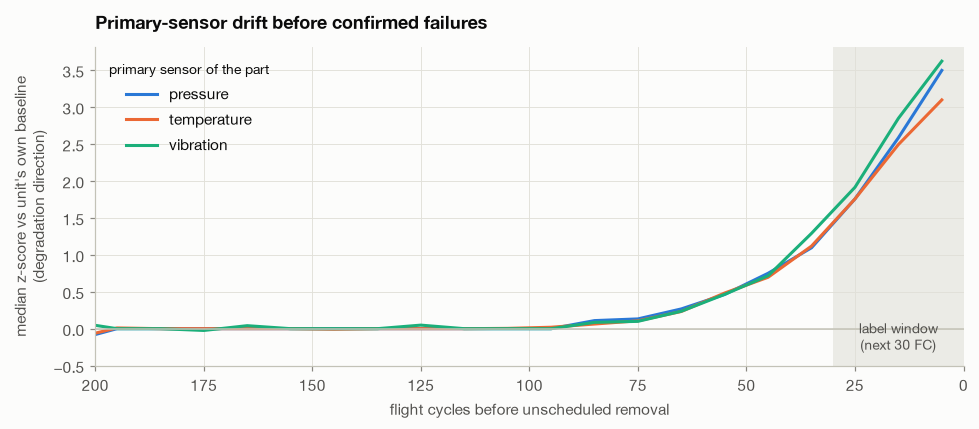

In [11]:
# Cycles-to-removal for every sensor reading of a unit that later had a confirmed failure
usage_sorted = usage.sort_values(["tail_no", "flight_date"])
usage_sorted["cum_fc"] = usage_sorted.groupby("tail_no").flight_cycles.cumsum()
cum_fc = usage_sorted.set_index(["tail_no", "flight_date"]).cum_fc

fail = removals.query("removal_reason == 'FAILURE_CONFIRMED'").merge(parts[["part_no", "primary_sensor"]], on="part_no")
fail["fc_at_removal"] = cum_fc.reindex(pd.MultiIndex.from_frame(fail[["tail_no", "removal_date"]])).values

col_of = {"vibration": "vibration_ips", "temperature": "temperature_c", "pressure": "pressure_psi"}
sign_of = {"vibration": 1, "temperature": 1, "pressure": -1}   # pressure drops when a pump/valve degrades
curves = {}
for ps, grp in fail.groupby("primary_sensor"):
    m = sensors.merge(grp[["tail_no", "position", "removal_date", "fc_at_removal"]], on=["tail_no", "position"])
    m = m[(m.reading_date < m.removal_date) & (m.reading_date >= m.removal_date - pd.Timedelta(days=60))]
    m["fc_to_removal"] = m.fc_at_removal - cum_fc.reindex(pd.MultiIndex.from_frame(m[["tail_no", "reading_date"]])).values
    v = m[col_of[ps]].where(~m[col_of[ps]].isin([0, -999, 9999]))
    key = ["tail_no", "position", "removal_date"]
    ref = v[m.fc_to_removal > 100].groupby([m[k] for k in key]).agg(["median", "std"])
    ref.index.names = key
    m = m.join(ref, on=key)
    m["z"] = sign_of[ps] * (v - m["median"]) / m["std"]
    m["bin"] = (m.fc_to_removal // 10 * 10).clip(upper=200)
    curves[ps] = m[m.fc_to_removal <= 200].groupby("bin").z.median()

fig, ax = plt.subplots(figsize=(9, 4))
ax.axvspan(0, HORIZON_FC, color=viz.GRID, alpha=0.6, lw=0)
ax.text(HORIZON_FC / 2, 0.04, "label window\n(next 30 FC)", transform=ax.get_xaxis_transform(),
        ha="center", va="bottom", fontsize=9, color=viz.INK_2)
for i, (ps, c) in enumerate(curves.items()):
    ax.plot(c.index + 5, c.values, color=viz.SERIES[i], label=ps)
ax.axhline(0, color=viz.BASELINE, lw=1)
ax.set_xlim(200, 0)
ax.set_ylim(-0.5, None)
ax.set_xlabel("flight cycles before unscheduled removal")
ax.set_ylabel("median z-score vs unit's own baseline\n(degradation direction)")
ax.set_title("Primary-sensor drift before confirmed failures")
ax.legend(loc="upper left", title="primary sensor of the part", title_fontsize=9)
fig.tight_layout()
viz.savefig(fig, "eda_precursor_sensor")
plt.show()

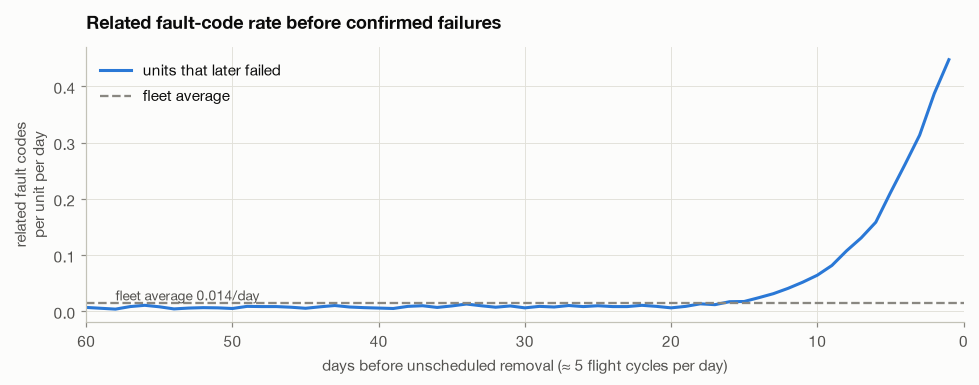

Lift in the final 7 days: 19x the fleet average


In [12]:
# Related fault codes per component-day before failure, vs the fleet baseline
related = faults[~faults.fault_code.str[:2].isin(["31", "23", "33", "45", "26", "30"])]
m = related.merge(fail[["tail_no", "position", "removal_date"]], on=["tail_no", "position"])
m["days_to_removal"] = (m.removal_date - m.fault_date).dt.days
m = m[(m.days_to_removal > 0) & (m.days_to_removal <= 60)]
per_day = m.groupby("days_to_removal").size() / len(fail)

comp_days = len(usage.query("flight_cycles > 0")) * parts.qty_per_aircraft.sum()
baseline = len(related) / comp_days

fig, ax = plt.subplots(figsize=(9, 3.6))
ax.plot(per_day.index, per_day.values, color=viz.SERIES[0], label="units that later failed")
ax.axhline(baseline, color=viz.MUTED, lw=1.5, ls="--", label="fleet average")
ax.text(58, baseline, f"fleet average {baseline:.3f}/day", color=viz.INK_2, fontsize=9, va="bottom")
ax.set_xlim(60, 0)
ax.set_xlabel("days before unscheduled removal (≈ 5 flight cycles per day)")
ax.set_ylabel("related fault codes\nper unit per day")
ax.set_title("Related fault-code rate before confirmed failures")
ax.legend(loc="upper left")
fig.tight_layout()
viz.savefig(fig, "eda_precursor_faults")
plt.show()
print(f"Lift in the final 7 days: {per_day.loc[1:7].mean() / baseline:.0f}x the fleet average")

**Finding:** a clear precursor exists, but it is **late**. Primary sensors start drifting about 90 FC before
removal, pass 1σ only around 35 FC before, and are strongly abnormal (2–3.5σ) inside the 30 FC label window.
Related fault codes rise from about two weeks out and reach ~19x the fleet average in the final week.

→ **Decision:** features must capture *recent change relative to the unit's own baseline*: short windows
(last 5–10 FC / 7 days) compared with a longer reference window, slopes, and fault counts over 3/7/30 days.
Absolute sensor levels alone would be dominated by part-number and unit-to-unit offsets.

## 6. Age / usage effect

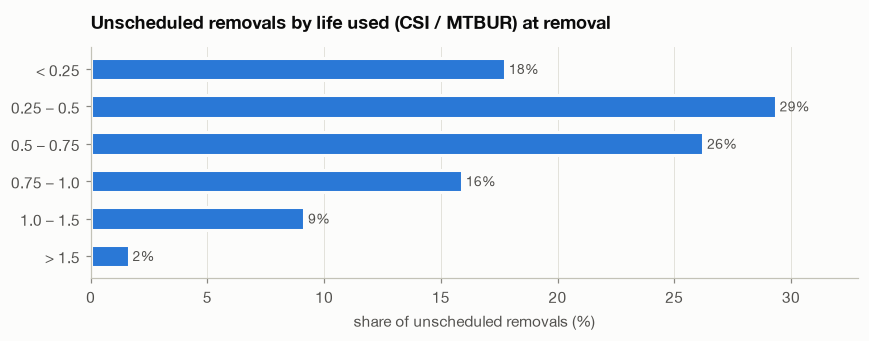

Removed before reaching 50% of MTBUR: 47%   |   past 100% of MTBUR: 11%


In [13]:
# Where in the unit's life do unscheduled removals happen? (cycles since installation / part MTBUR)
u = removals.query("removal_type == 'UNSCHEDULED'").merge(parts[["part_no", "mtbur_fc"]], on="part_no")
u["life_used"] = u.csi_at_removal / u.mtbur_fc
bins = [0, 0.25, 0.5, 0.75, 1.0, 1.5, 10]
labels = ["< 0.25", "0.25 – 0.5", "0.5 – 0.75", "0.75 – 1.0", "1.0 – 1.5", "> 1.5"]
dist = pd.cut(u.life_used, bins, labels=labels).value_counts(normalize=True).sort_index()
fig, ax = plt.subplots(figsize=(8, 3.2))
viz.barh(ax, dist.index.astype(str), dist.values * 100, fmt="{:.0f}%")
ax.set_title("Unscheduled removals by life used (CSI / MTBUR) at removal")
ax.set_xlabel("share of unscheduled removals (%)")
fig.tight_layout()
viz.savefig(fig, "eda_life_used")
plt.show()
print(f"Removed before reaching 50% of MTBUR: {(u.life_used < 0.5).mean():.0%}   |   past 100% of MTBUR: {(u.life_used > 1).mean():.0%}")

**Finding:** unscheduled removals are spread across the whole life of a unit. A large share happens well
before MTBUR and some units run far past it. Age raises the risk (Weibull wear-out) but is a weak separator
on its own, so a pure age-based rule makes a poor baseline. → `csi_over_mtbur` stays as a feature and the baseline rule is used to show what ML adds.

## 7. Leakage traps

In [14]:
moved = ins.groupby("serial_no").tail_no.nunique()
print(f"Serials installed on more than one tail: {(moved > 1).sum():,} of {len(moved):,} ({(moved > 1).mean():.0%})")
repeat = removals.query("removal_type == 'UNSCHEDULED'").groupby("serial_no").size()
print(f"Serials with 2+ unscheduled removals: {(repeat >= 2).sum():,}")
print("shop_finding values:", removals.shop_finding.unique().tolist())

Serials installed on more than one tail: 1,337 of 1,640 (82%)
Serials with 2+ unscheduled removals: 867
shop_finding values: ['INTERNAL_CORROSION', 'NO_FAULT_FOUND', 'ELECTRICAL_FAULT', 'BEARING_WEAR', 'CONTAMINATION', 'SEAL_LEAK', 'ROUTINE_OVERHAUL']


| Trap | Why it leaks | Handling |
|---|---|---|
| Random row split | Consecutive weekly snapshots of the same unit are near-duplicates, and a label window can overlap train and test | **Time-based split** with a 30 FC embargo between periods |
| Same aircraft in train and test | Tail-specific behaviour (base, utilisation, data-link quality) is memorised | **Hold out whole tails** for the test set |
| Same serial on two tails | Rotables move between aircraft after shop visits, so a tail-only split still leaks the unit's history | Hold out by **serial number** too: units ever seen in train are removed from the test set |
| `shop_finding`, `removal_reason` | Only known *after* removal | Never used as features |
| Fleet statistics (part baselines, target encoding) | Computed on all data they encode the future | Fit on the training period only |
| Rolling features | A centred or forward window sees the future | Backward-looking windows ending at the snapshot date only |

## 8. Decisions carried into the pipeline

| Topic | Decision |
|---|---|
| Unit of prediction | component serial × weekly snapshot date |
| Label | 1 if an **unscheduled** removal (incl. NFF) occurs within the next 30 flight cycles |
| Censoring | drop snapshots with < 30 FC of follow-up at the end of the data; stop a unit's snapshots at removal |
| Missing data | NaN-aware rolling stats + missingness features; trees handle NaN, linear model gets train medians |
| Outliers | sentinel codes → NaN, robust-z spike removal, median-based aggregation |
| Categorical | `ata_chapter`, `climate_zone`, `aircraft_type` → one-hot / native; `part_no` → out-of-fold target encoding |
| Imbalance (~2%) | class weights; evaluation on the natural 2% rate; PR-AUC and recall @ 5% alert rate |
| Key features | recent sensor change vs own baseline, related fault counts, age vs MTBUR, prior removals / NFF, climate |